# 🎓 Smart Career Path Recommendation — New Model Training Notebook

**Project:** Smart Career Path Recommendation System for Nigerian Secondary School Students  
**Classes:** SSS 1, SSS 2, and SS3
**Data source:** Google Form Responses  
**Models:** Random Forest (baseline) + XGBoost (primary)  
**Target:** 10 Nigerian career path labels

---

## Folder structure expected
```
├── new_model.ipynb          ← This notebook
├── data/
│   └── Nigerian Career Survey (Responses).xlsx
└── backend/
    └── models/                ← Trained .pkl files saved here
```

# Libraries and Data Check

In [123]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import joblib


def prepare_feature_frame(df_input, feature_names, categorical_features, numerical_features):
    df_proc = df_input.copy()
    df_proc.columns = [str(c).strip().lower().replace(" ", "_").replace("__", "_") for c in df_proc.columns]
    df_proc = df_proc.rename(columns={"igbo_/_hausa": "igbo_hausa"})

    normalized_feature_names = [str(c).strip().lower().replace(" ", "_").replace("__", "_") for c in feature_names]
    normalized_categorical = [str(c).strip().lower().replace(" ", "_").replace("__", "_") for c in categorical_features]
    normalized_numerical = [str(c).strip().lower().replace(" ", "_").replace("__", "_") for c in numerical_features]

    for col in normalized_categorical:
        if col in df_proc.columns:
            df_proc[col] = df_proc[col].fillna("Unknown")
            df_proc[col] = df_proc[col].astype(str).replace({"0": "Unknown", "0.0": "Unknown", "nan": "Unknown", "None": "Unknown"})
        else:
            df_proc[col] = "Unknown"

    for col in normalized_numerical:
        if col in df_proc.columns:
            series_value = df_proc[col].squeeze()
            if isinstance(series_value, pd.DataFrame):
                series_value = series_value.iloc[:, 0]
            df_proc[col] = pd.to_numeric(series_value, errors="coerce")
            df_proc[col] = df_proc[col].fillna(0.0)
        else:
            df_proc[col] = 0.0

    for col in normalized_feature_names:
        if col not in df_proc.columns:
            df_proc[col] = 0.0 if col in normalized_numerical else "Unknown"

    return df_proc.loc[:, normalized_feature_names].copy()

In [124]:
repo_root = Path.cwd()
if (repo_root / "new_model.ipynb").exists():
    data_path = repo_root / "data" / "combined_career_dataset.xlsx"
else:
    data_path = repo_root / ".." / "data" / "combined_career_dataset.xlsx"

print(f"Using data file: {data_path}")
data = pd.read_excel(data_path)
df = pd.DataFrame(data)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

Using data file: c:\Users\USER\Documents\GitHub uploads\Smart-Career-Portal\data\combined_career_dataset.xlsx


# Data Cleaning

In [125]:
df = df.copy()
df = df.loc[:, ~df.columns.duplicated()].copy()
df = df.reset_index(drop=True)
df = df.fillna(0)
df = df.rename(columns=lambda x: x.removesuffix('_waec'))

# Drop empty (0) values in Career Path, Class Departments, School Type, intended career path, Universty Level, Academic Strength, Best Subject Category, Current Career Satisfaction
cols_to_clean = ['career_path', 'department', 'school_type', 'intended_career_path', 'university_level', 'academic_strength', 'best_subject_category', 'current_career_satisfaction']
df[cols_to_clean] = df[cols_to_clean].replace(0, np.nan)
df['jamb_score'] = df['jamb_score'].replace("I don't remember ", 0)

# Keep the row but fill missing career labels using the intended career path when possible.
df['career_path'] = df['career_path'].replace({0: np.nan, '': np.nan, '0': np.nan})
df['career_path'] = df['career_path'].fillna(df['intended_career_path'])
df['career_path'] = df['career_path'].replace({0: np.nan, '': np.nan, '0': np.nan})

# Drop rows that still have no career label after imputation.
df = df.dropna(subset=['career_path'])

# Drop Age column
df = df.drop(columns=['age', 'name'])

# Clean CGPA column
def clean_cgpa(value):
    if pd.isna(value) or value is None:
        return np.nan
    val = str(value).strip().lower()
    refuse_keywords = [
        "rather not", "don't remember", "i don't", "none", 
        "nil", "n/a", "na", "not sure", "prefer not"
    ]
    if any(kw in val for kw in refuse_keywords) or val in ["", "none", "nil"]:
        return np.nan
    if "/" in val:
        parts = val.split("/")
        try:
            numerator = float(re.sub(r"[^\d.]", "", parts[0]))
            return round(numerator, 2)
        except:
            return np.nan
    val = val.replace(":", ".")
    cleaned = re.sub(r"[^\d.]", "", val)
    if cleaned.count(".") > 1 or cleaned == "" or cleaned == ".":
        return np.nan
    try:
        num = float(cleaned)
        if 0 <= num <= 5.0:
            return round(num, 2)
        elif 5 < num <= 100:          
            return round(num / 20, 2) 
        else:
            return np.nan
    except:
        return np.nan
# Apply cleaning
df["cgpa"] = df["cgpa"].apply(clean_cgpa)

# Convert WAEC to int
df['waec_year'] = df['waec_year'].astype(int)
df['waec_credits'] = df['waec_credits'].astype(int)
df['jamb_score'] = df['jamb_score'].astype(int)

print(f"Shape of dataset: rows={df.shape[0]}, columns={df.shape[1]}")
print("\nDistribution of Labels (target variables):")
print(df['career_path'].value_counts())
print("\nDistribution of Class Departments:")
print(df['department'].value_counts())
print("\nDistribution of school type:")
print(df['school_type'].value_counts())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nRows with missing career path after cleaning:", df['career_path'].isna().sum())
print("\nThe Dataset after cleaning:")
display(df.head(10))


Shape of dataset: rows=406, columns=40

Distribution of Labels (target variables):
career_path
Education & Humanities                  72
Computer Science & IT                   61
Medicine & Health Sciences              60
Engineering & Technology                48
Agriculture & Environmental Sciences    41
Business & Finance                      27
Law & Social Sciences                   25
Entrepreneurship & Management           25
Creative Arts & Design                  24
Mass Communication & Media              23
Name: count, dtype: int64

Distribution of Class Departments:
department
Science       321
Arts           57
Commercial     28
Name: count, dtype: int64

Distribution of school type:
school_type
Government School         216
Private School            184
Mission / Faith School      5
Name: count, dtype: int64

Missing Values:
timestamp                                                                 0
gender                                                                 

,timestamp,gender,school_type,waec_year,department,mathematics,english,civic_education,physics,chemistry,biology,further_mathematics,agricultural_science,geography,technical_drawing,computer_studies,yoruba,igbo_hausa,data_processing,literature_in_english,history,christian_religious_studies_islamic_studies,french,creative_arts,economics,financial_accounting,commerce,government,marketing,academic_strength,waec_credits,best_subject_category,cgpa,jamb_score,career_path,current_career_satisfaction,add_any_subject_not_listed_in_the_form_and_the_grade_eg_mathematics_a,university_level,intended_career_path,career_influence
0,2026-07-18 09:50:58.737000,Female,Private School,2020,Arts,B,B,B,0,0,0,0,0,0,0,0,C,0,0,C,0,B,0,A,0,0,0,0,0,Average,2,Arts,0.00,0,Business & Finance,Not very confident,0,200 Level,Business & Finance,0
2,2026-07-18 10:06:13.332000,Female,Government School,2023,Science,B,B,C,B,B,B,0,A,0,0,0,0,0,0,0,0,0,0,0,C,0,0,0,C,Average,2,Science,0.00,230,Agriculture & Environmental Sciences,Still adapting,Photography :A,100 Level,Computer Science & IT,Mother
3,2026-07-18 10:09:33.877000,Female,Private School,2021,Science,B,B,A,B,B,B,0,A,0,0,B,0,0,0,0,0,0,0,0,B,0,0,0,0,Average,9,Science,3.50,250,Medicine & Health Sciences,Somewhat confident,Trade subject -A,400 Level,Medicine & Health Sciences,My dad
4,2026-07-18 10:12:40.150000,Male,Private School,2020,Science,A,B,B,A,A,A,A,A,A,A,A,A,C,A,D,C,A,A,A,A,A,A,A,A,High,1,Science,4.97,367,Engineering & Technology,Still adapting,0,400 Level,Engineering & Technology,A lot of things
5,2026-07-18 10:12:47.412000,Female,Private School,2023,Science,A,C,A,B,B,A,A,0,0,B,0,0,0,0,0,0,0,0,0,B,0,0,0,0,High,8,Science,4.43,285,Engineering & Technology,Very confident,0,300 Level,Engineering & Technology,Books
6,2026-07-18 10:19:56.732000,Female,Private School,2023,Science,A,B,A,A,B,A,A,0,0,0,0,0,0,0,0,0,0,0,0,B,0,0,0,0,High,0,Science,4.98,355,Engineering & Technology,Somewhat confident,0,300 Level,Engineering & Technology,The ever changing world
7,2026-07-18 10:31:31.515000,Female,Private School,2023,Science,B,A,A,B,B,A,C,A,0,0,A,0,0,0,0,0,0,0,0,B,0,0,0,0,High,2,Science,4.10,296,Medicine & Health Sciences,Very confident,0,200 Level,Medicine & Health Sciences,My mum
8,2026-07-18 10:40:04.090000,Female,Government School,2020,Science,B,B,B,B,A,B,0,B,B,0,B,0,0,0,0,0,0,0,0,B,0,0,0,0,High,1,Science,3.78,220,Computer Science & IT,Very confident,0,500 Level,Medicine & Health Sciences,Society
9,2026-07-18 13:20:22.700000,Female,Private School,2021,Commercial,B,B,A,0,0,B,0,0,0,0,0,0,0,0,0,0,0,0,0,B,B,B,B,0,High,0,Commerce,0.00,269,Business & Finance,Still adapting,0,400 Level,NaN,0
10,2026-07-18 17:08:42.125000,Male,Private School,2023,Science,A,C,A,C,C,A,0,0,0,0,A,0,0,0,0,0,0,0,0,A,0,0,0,0,Average,9,Science,4.66,296,Medicine & Health Sciences,Very confident,0,300 Level,Medicine & Health Sciences,Desire


# Exploratory Data Analysis

intended_career_path                  career_path                         
Agriculture & Environmental Sciences  Agriculture & Environmental Sciences    23
Business & Finance                    Agriculture & Environmental Sciences     7
                                      Business & Finance                      22
                                      Computer Science & IT                    5
                                      Education & Humanities                   2
                                      Entrepreneurship & Management            5
Computer Science & IT                 Agriculture & Environmental Sciences     2
                                      Business & Finance                       4
                                      Computer Science & IT                   39
                                      Creative Arts & Design                  15
                                      Education & Humanities                   2
Creative Arts & Design            

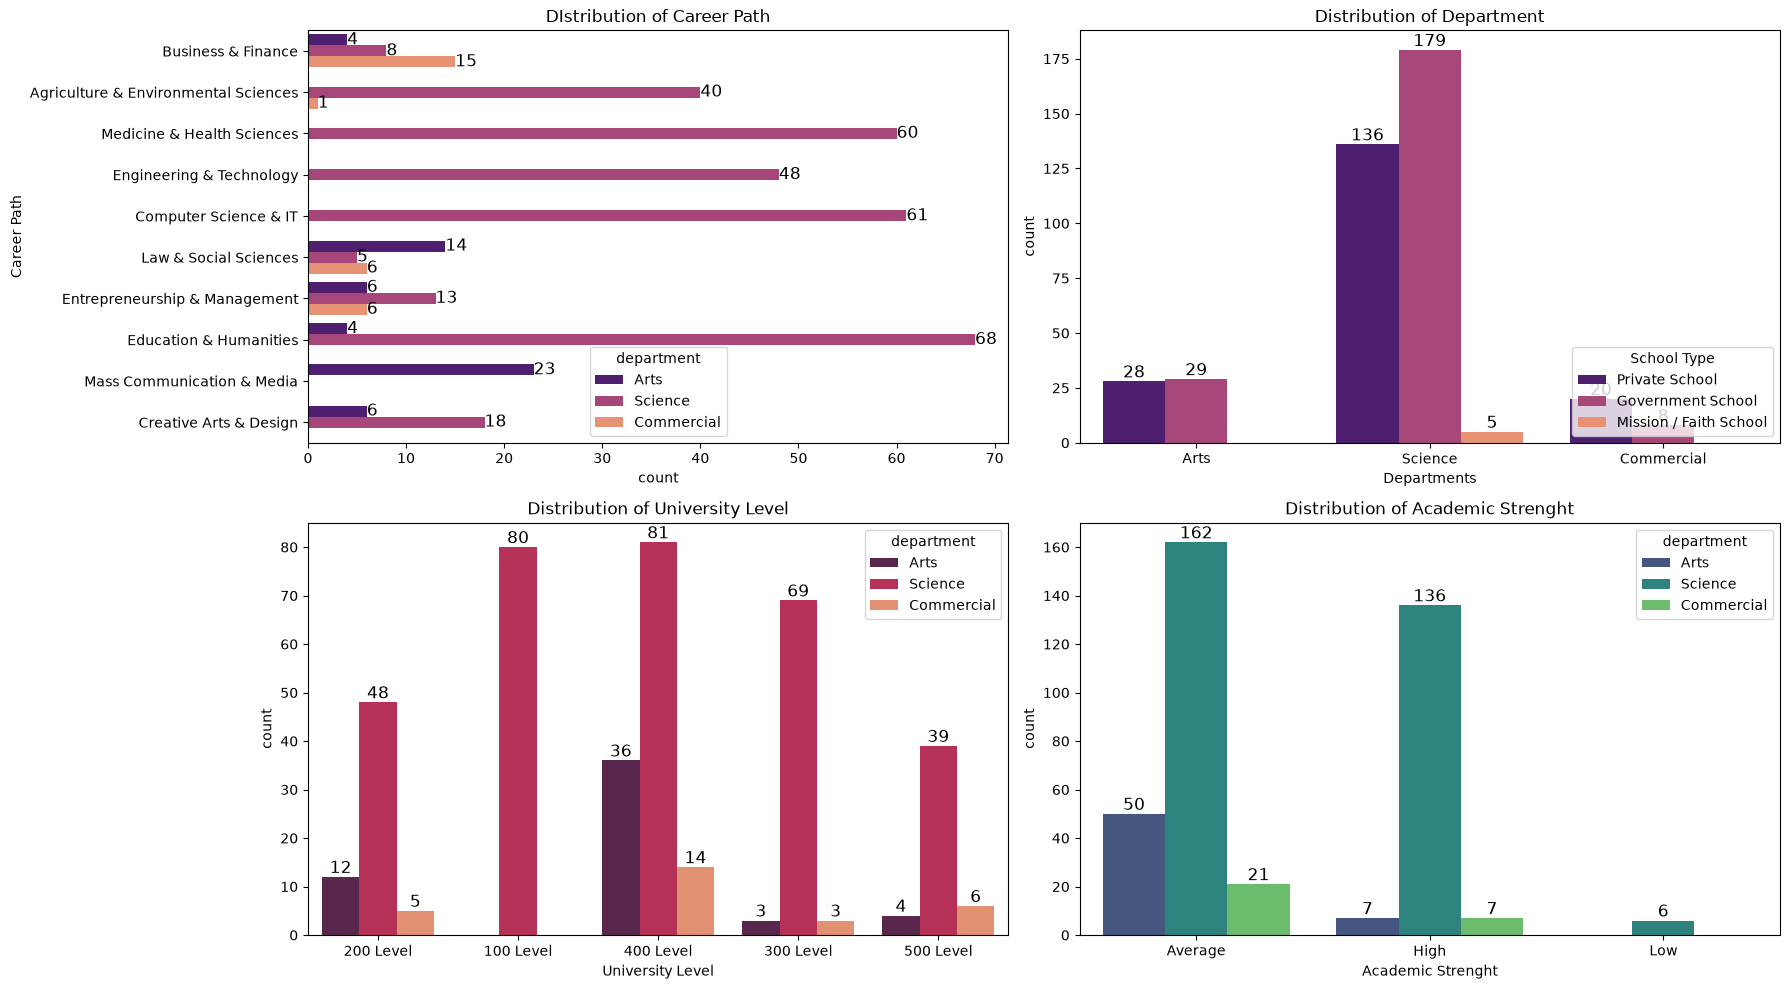

In [126]:
# Career Paths Analysis
career_path_analysis = df.groupby(['intended_career_path', 'career_path'], observed=True).agg('size')
display(career_path_analysis)
plt.figure(figsize=(18, 10))
plt.subplot(2, 2, 1)

# Distribution of Career path
sns.countplot(y="career_path", data=df, hue="department", palette="magma")
for container in plt.gca().containers:
    plt.bar_label(container, fontsize=12)
plt.title("DIstribution of Career Path")
plt.ylabel("Career Path")

# Distribution of departments
plt.subplot(2, 2, 2)
sns.countplot(x="department", data=df, hue="school_type", palette="magma")
plt.title("Distribution of Department")
for container in plt.gca().containers:
    plt.bar_label(container, fontsize=12)
plt.xlabel("Departments")
plt.legend(title="School Type", loc="lower right")

# Distribution of Age
plt.subplot(2, 2, 3)
sns.countplot(x="university_level", data=df, palette='rocket', hue='department')
for container in plt.gca().containers:
    plt.bar_label(container, fontsize=12)
plt.title("Distribution of University Level")
plt.xlabel("University Level")

# Distribution of Acadmic Strenght
plt.subplot(2, 2, 4)
sns.countplot(x="academic_strength", data=df, hue="department", palette="viridis")
plt.title("Distribution of Academic Strenght")
for container in plt.gca().containers:
    plt.bar_label(container, fontsize=12)
plt.xlabel("Academic Strenght")

plt.tight_layout()
plt.show()


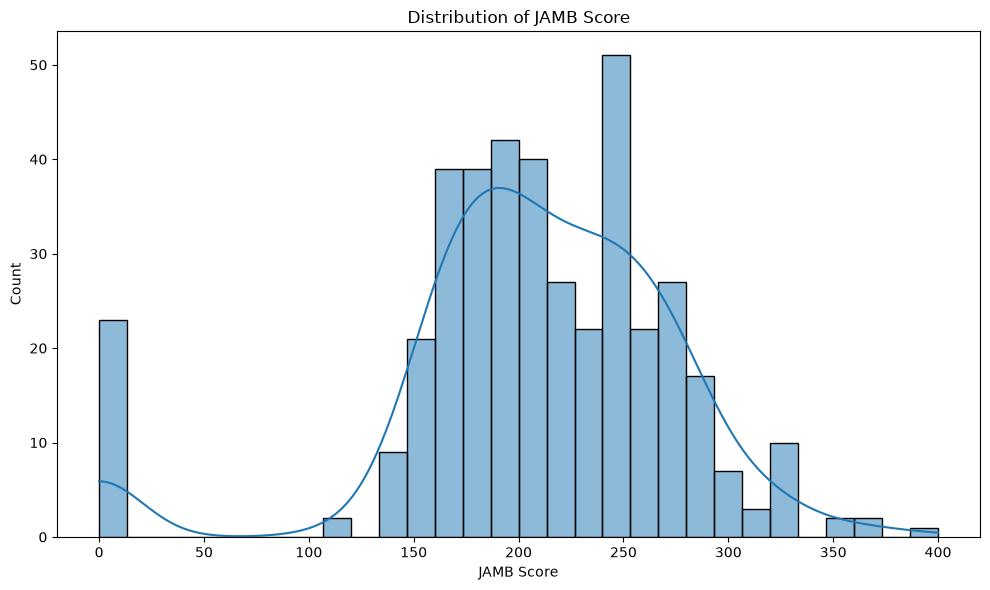

In [127]:
# Distribution of other features
plt.figure(figsize=(10, 6))

# JAMB
sns.histplot(df['jamb_score'].dropna(), bins=30, kde=True)
plt.title("Distribution of JAMB Score")
plt.xlabel("JAMB Score")

plt.tight_layout()
plt.show()

# Preprocessing Pipeline for Feature Engineering, Scaling and Encoding

In [128]:
subjects_cols = ["mathematics", "english", "civic_education", "physics", "chemistry", "biology", "further_mathematics", "agricultural_science", "geography", "technical_drawing", "computer_studies", "yoruba", "igbo_hausa", "data_processing",
                 "literature_in_english", "christian_religious_studies_islamic_studies", "creative_arts", "economics", "financial_accounting", "commerce", "government", "marketing", "french", "intended_career_path"]
categorical_columns = ["gender", "school_type", "department", "academic_strength", "best_subject_category", "current_career_satisfaction", "career_influence"] + subjects_cols
numerical_columns = ["waec_year", "waec_credits", "cgpa", "jamb_score"]

# Ensure preprocessor uses the normalized column names (underscores) to match X_train
cat_cols_norm = [c.lower().strip().replace(' ', '_').replace('__', '_') for c in categorical_columns]
num_cols_norm = [c.lower().strip().replace(' ', '_').replace('__', '_') for c in numerical_columns]
for col in cat_cols_norm:
    if col in df.columns:
        df[col] = df[col].replace({0: 'Unknown', 0.0: 'Unknown', np.nan: 'Unknown'}).astype(str)
for col in num_cols_norm:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols_norm),
    ('cat', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols_norm)
])
features = cat_cols_norm + num_cols_norm
display(preprocessor)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

# Build Feature Matrix

In [129]:
label_encoder = LabelEncoder()


X = df[features].copy()
y = df["career_path"].dropna()
y_encoded = label_encoder.fit_transform(y)

print("First 5 rows of X (Features):")
display(X.head())
print("\nDistribution of y (target):")
print(y.value_counts())
print("\nUnique classes in target variable:", label_encoder.classes_)

print("\nClass imbalance summary:")
for i, (class_label, count) in enumerate(zip(label_encoder.classes_, y.value_counts())):
    print(f"  {class_label}: {count}")

First 5 rows of X (Features):


,gender,school_type,department,academic_strength,best_subject_category,current_career_satisfaction,career_influence,mathematics,english,civic_education,physics,chemistry,biology,further_mathematics,agricultural_science,geography,technical_drawing,computer_studies,yoruba,igbo_hausa,data_processing,literature_in_english,christian_religious_studies_islamic_studies,creative_arts,economics,financial_accounting,commerce,government,marketing,french,intended_career_path,waec_year,waec_credits,cgpa,jamb_score
0,Female,Private School,Arts,Average,Arts,Not very confident,Unknown,B,B,B,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,C,Unknown,Unknown,C,B,A,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Business & Finance,2020,2,0.00,0
2,Female,Government School,Science,Average,Science,Still adapting,Mother,B,B,C,B,B,B,Unknown,A,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,C,Unknown,Unknown,Unknown,C,Unknown,Computer Science & IT,2023,2,0.00,230
3,Female,Private School,Science,Average,Science,Somewhat confident,My dad,B,B,A,B,B,B,Unknown,A,Unknown,Unknown,B,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,B,Unknown,Unknown,Unknown,Unknown,Unknown,Medicine & Health Sciences,2021,9,3.50,250
4,Male,Private School,Science,High,Science,Still adapting,A lot of things,A,B,B,A,A,A,A,A,A,A,A,A,C,A,D,A,A,A,A,A,A,A,A,Engineering & Technology,2020,1,4.97,367
5,Female,Private School,Science,High,Science,Very confident,Books,A,C,A,B,B,A,A,Unknown,Unknown,B,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,B,Unknown,Unknown,Unknown,Unknown,Unknown,Engineering & Technology,2023,8,4.43,285



Distribution of y (target):
career_path
Education & Humanities                  72
Computer Science & IT                   61
Medicine & Health Sciences              60
Engineering & Technology                48
Agriculture & Environmental Sciences    41
Business & Finance                      27
Law & Social Sciences                   25
Entrepreneurship & Management           25
Creative Arts & Design                  24
Mass Communication & Media              23
Name: count, dtype: int64

Unique classes in target variable: ['Agriculture & Environmental Sciences' 'Business & Finance'
 'Computer Science & IT' 'Creative Arts & Design' 'Education & Humanities'
 'Engineering & Technology' 'Entrepreneurship & Management'
 'Law & Social Sciences' 'Mass Communication & Media'
 'Medicine & Health Sciences']

Class imbalance summary:
  Agriculture & Environmental Sciences: 72
  Business & Finance: 61
  Computer Science & IT: 60
  Creative Arts & Design: 48
  Education & Humanities: 41
  Engi

# Train Test Split (80/20)

In [130]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, shuffle=True, stratify=y_encoded)
print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print("Class balance in train:")
for i, (class_label, count) in enumerate(zip(label_encoder.classes_, np.unique(y_train, return_counts=True)[1])):
    print(f"  {class_label}: {count}")
print("\nClass balance in test:")
for i, (class_label, count) in enumerate(zip(label_encoder.classes_, np.unique(y_test, return_counts=True)[1])):
    print(f"  {class_label}: {count}")



Train size: 324 | Test size: 82
Class balance in train:
  Agriculture & Environmental Sciences: 33
  Business & Finance: 22
  Computer Science & IT: 49
  Creative Arts & Design: 19
  Education & Humanities: 57
  Engineering & Technology: 38
  Entrepreneurship & Management: 20
  Law & Social Sciences: 20
  Mass Communication & Media: 18
  Medicine & Health Sciences: 48

Class balance in test:
  Agriculture & Environmental Sciences: 8
  Business & Finance: 5
  Computer Science & IT: 12
  Creative Arts & Design: 5
  Education & Humanities: 15
  Engineering & Technology: 10
  Entrepreneurship & Management: 5
  Law & Social Sciences: 5
  Mass Communication & Media: 5
  Medicine & Health Sciences: 12


# Baseline Model - Random Forest

In [131]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=18,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Fit the model
rf_model.fit(X_train, y_train)

# Evaluation
rf_train_accuracy = accuracy_score(y_train, rf_model.predict(X_train))
rf_test_accuracy = accuracy_score(y_test, rf_model.predict(X_test))
print(f"Random Forest Train Accuracy: {rf_train_accuracy*100:.2f}%")
print(f"Random Forest Test Accuracy: {rf_test_accuracy*100:.2f}%")

# Classification Report
rf_target_names = [str(c) if not (isinstance(c, float) and np.isnan(c)) else "Unknown" for c in label_encoder.classes_]
rf_classification_report = classification_report(y_test, rf_model.predict(X_test), target_names=rf_target_names, zero_division=0)
print("\nClassification Report for Random Forest Model:")
print(rf_classification_report)

Random Forest Train Accuracy: 99.07%
Random Forest Test Accuracy: 86.59%

Classification Report for Random Forest Model:
                                      precision    recall  f1-score   support

Agriculture & Environmental Sciences       1.00      0.88      0.93         8
                  Business & Finance       0.71      1.00      0.83         5
               Computer Science & IT       0.89      0.67      0.76        12
              Creative Arts & Design       1.00      0.80      0.89         5
              Education & Humanities       0.81      0.87      0.84        15
            Engineering & Technology       0.82      0.90      0.86        10
       Entrepreneurship & Management       1.00      0.80      0.89         5
               Law & Social Sciences       1.00      0.80      0.89         5
          Mass Communication & Media       1.00      1.00      1.00         5
          Medicine & Health Sciences       0.80      1.00      0.89        12

                   

## Visualize Random Forest Classification Report 

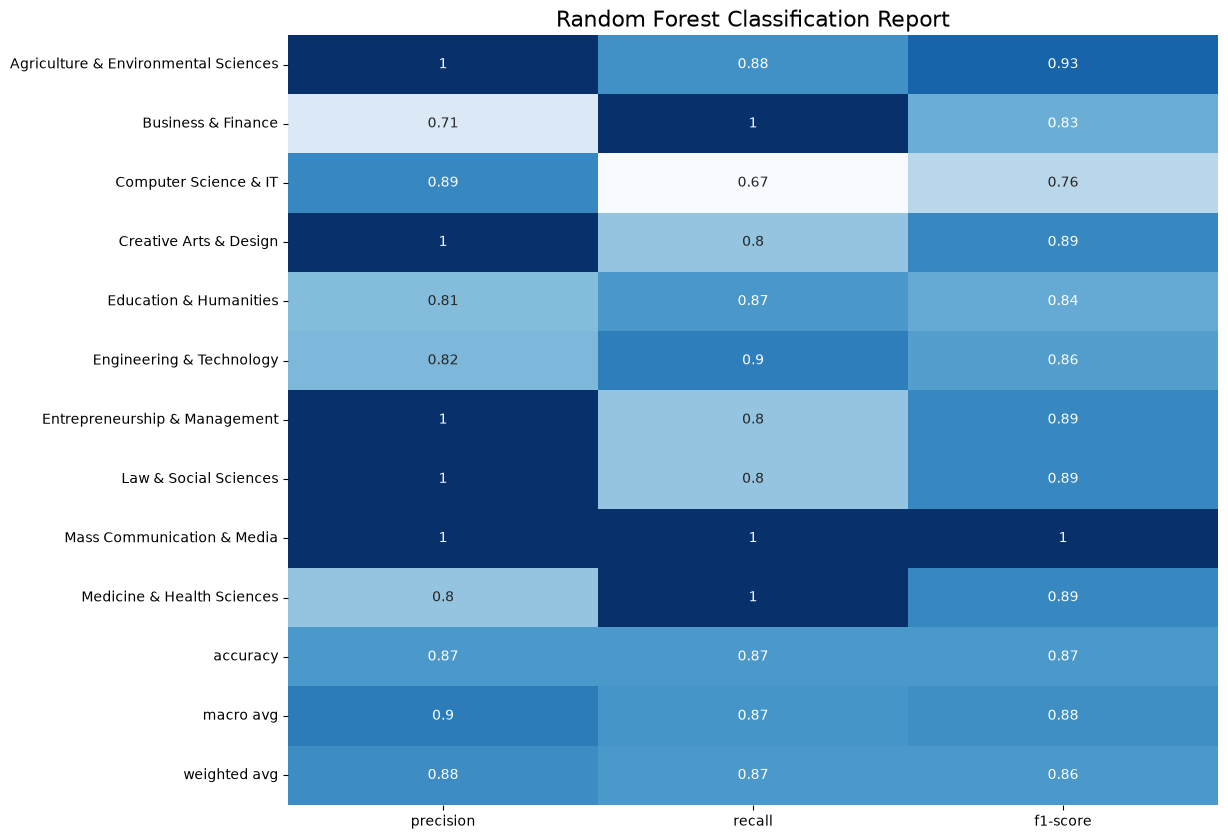

In [132]:
rf_classification_report_dict = classification_report(y_test, rf_model.predict(X_test), target_names=label_encoder.classes_, output_dict=True, zero_division=0)

# Plot Random Forest Classification Report
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pd.DataFrame(rf_classification_report_dict).iloc[:-1, :].T, annot=True, cmap="Blues", cbar=False, ax=ax)
ax.set_title("Random Forest Classification Report", fontsize=16)
#plt.savefig("ml/models/classification_report.png", dpi=120, bbox_inches="tight")
plt.show()

# Primary Model - XGBoost 

In [133]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=400,
    max_depth=8,
    learning_rate=0.01,
    subsample=0.85,
    colsample_bytree=0.80,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0))
])

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
xgb_model.fit(X_train, y_train, classifier__sample_weight=sample_weights)

# Evaluation
xgb_train_accuracy = accuracy_score(y_train, xgb_model.predict(X_train))
xgb_test_accuracy = accuracy_score(y_test, xgb_model.predict(X_test))
print(f"XGBoost Train Accuracy: {xgb_train_accuracy*100:.2f}%")
print(f"XGBoost Test Accuracy: {xgb_test_accuracy*100:.2f}%")

# Classification Report
xgb_classification_report = classification_report(y_test, xgb_model.predict(X_test), target_names=label_encoder.classes_, zero_division=0)
print("\nXGBoost Classification Report:")
print(xgb_classification_report)

XGBoost Train Accuracy: 100.00%
XGBoost Test Accuracy: 84.15%

XGBoost Classification Report:
                                      precision    recall  f1-score   support

Agriculture & Environmental Sciences       0.89      1.00      0.94         8
                  Business & Finance       1.00      1.00      1.00         5
               Computer Science & IT       0.88      0.58      0.70        12
              Creative Arts & Design       1.00      0.80      0.89         5
              Education & Humanities       0.80      0.80      0.80        15
            Engineering & Technology       0.75      0.90      0.82        10
       Entrepreneurship & Management       1.00      0.80      0.89         5
               Law & Social Sciences       1.00      0.80      0.89         5
          Mass Communication & Media       0.83      1.00      0.91         5
          Medicine & Health Sciences       0.73      0.92      0.81        12

                            accuracy          

## Visualize XGBoost Classification Report

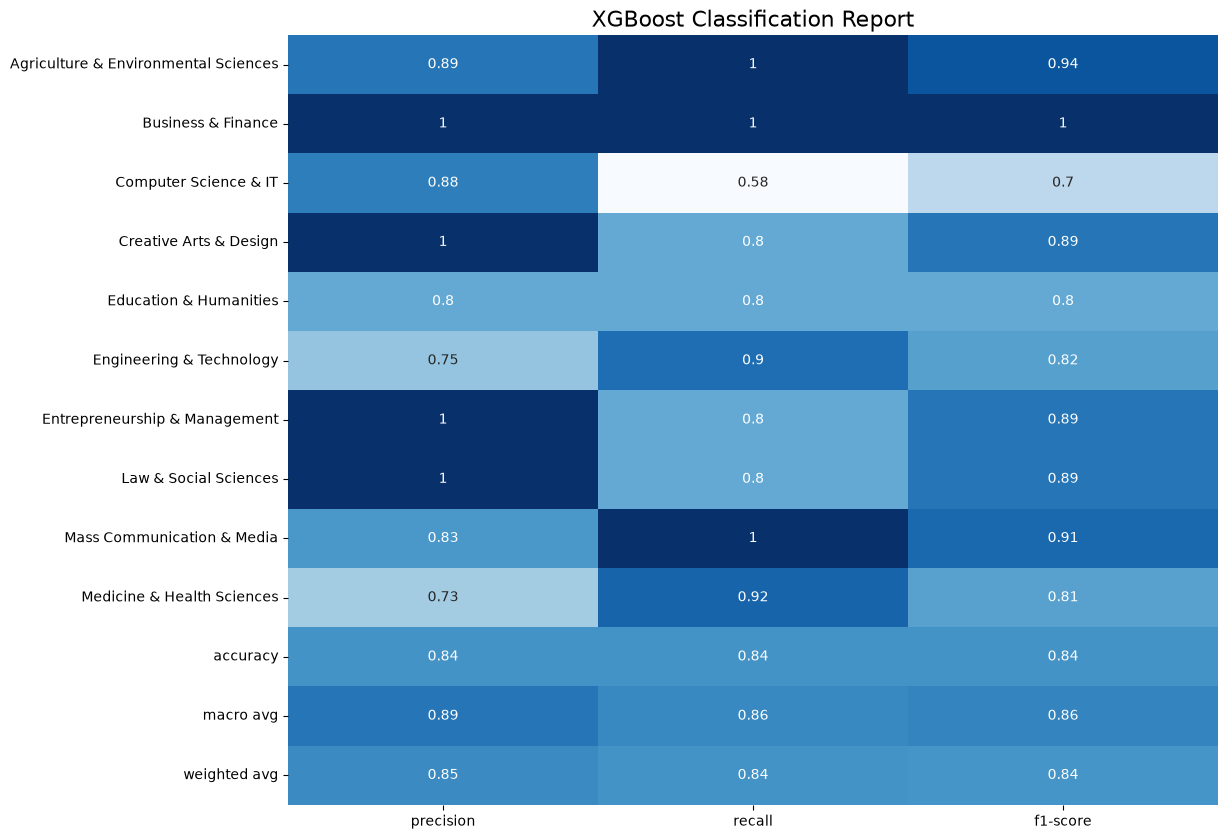

In [134]:
xgb_classification_report_dict = classification_report(y_test, xgb_model.predict(X_test), target_names=label_encoder.classes_, output_dict=True, zero_division=0)
# Plot Random Forest Classification Report
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pd.DataFrame(xgb_classification_report_dict).iloc[:-1, :].T, annot=True, cmap="Blues", cbar=False, ax=ax)
ax.set_title("XGBoost Classification Report", fontsize=16)
#plt.savefig("ml/models/classification_report.png", dpi=120, bbox_inches="tight")
plt.show()

# Hyperparameter Tuning - XGBoost

In [135]:
param_distributions = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__learning_rate': [0.01, 0.1, 0.2, 0.3],
    'classifier__max_depth': [3, 5, 7, 9],
    'classifier__min_child_weight': [1, 3, 5, 7],
    'classifier__gamma': [0, 0.1, 0.2, 0.3],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Fit to data
xgb_random_search.fit(X_train, y_train)

# Access results
print(f"Best Parameters: {xgb_random_search.best_params_}")
print(f"Best CV Score: {xgb_random_search.best_score_:.4f}")
print(f"Best Estimator: {xgb_random_search.best_estimator_}")

# Fit best model
xgb_best_model = xgb_random_search.best_estimator_

# Predict on validation and test set
xgb_best_model_pred = xgb_best_model.predict(X_test)
xgb_best_test_accuracy = (xgb_best_model_pred == y_test).mean()
print(f"Test accuracy of tuned XGBoost: {xgb_best_test_accuracy*100:.2f}%")
print(f"Train Accuracy of Tuned XGBoost: {accuracy_score(y_train, xgb_best_model.predict(X_train))*100:.2f}%")
print(f"Accuracy Score for Xgboost before tuning: {xgb_test_accuracy}")
print(f"Model Improvement: {(xgb_best_test_accuracy - xgb_test_accuracy)*100:.2f}%")

Best Parameters: {'classifier__subsample': 1.0, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 1, 'classifier__max_depth': 9, 'classifier__learning_rate': 0.01, 'classifier__gamma': 0.2, 'classifier__colsample_bytree': 0.6}
Best CV Score: 0.8734
Best Estimator: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['waec_year', 'waec_credits',
                                                   'cgpa', 'jamb_score']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['gender', 'school_type',
                                                   'department',
                                                   'academic_strength',
  

# Cross Validation and Model Comparison

In [136]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv  = cross_val_score(rf_model, X, y_encoded, cv=cv, scoring="accuracy", n_jobs=-1)
xgb_cv = cross_val_score(xgb_best_model, X, y_encoded, cv=cv, scoring="accuracy", n_jobs=-1)

print(f"Random Forest  CV: {rf_cv.mean()*100:.2f}% ± {rf_cv.std()*100:.2f}%")
print(f"XGBoost Tuned  CV: {xgb_cv.mean()*100:.2f}% ± {xgb_cv.std()*100:.2f}%")

Random Forest  CV: 85.71% ± 1.90%
XGBoost Tuned  CV: 88.17% ± 3.30%


# Confusion Matrix and Classification Report (XGBoost Tuned Model)

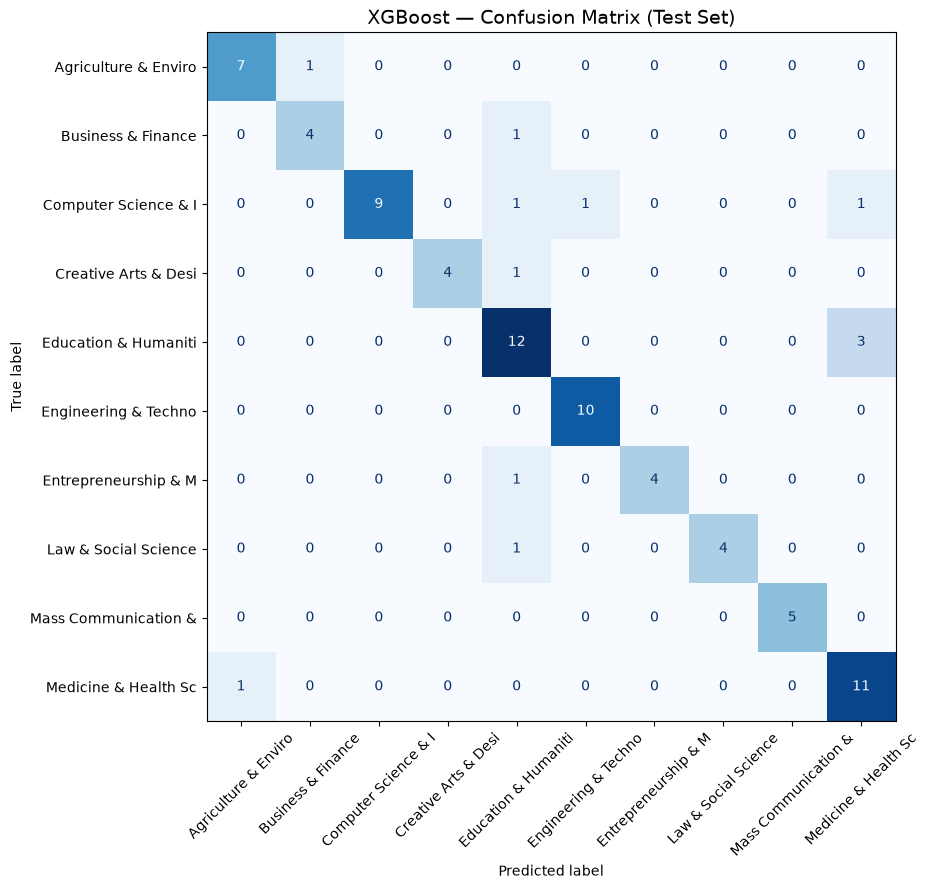

In [137]:
fig, ax = plt.subplots(figsize=(12, 9))
cm = confusion_matrix(y_test, xgb_best_model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[c[:20] for c in label_encoder.classes_])
disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap="Blues")
ax.set_title("XGBoost — Confusion Matrix (Test Set)", fontsize=14)
plt.tight_layout()
# plt.savefig("ml/models/confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()


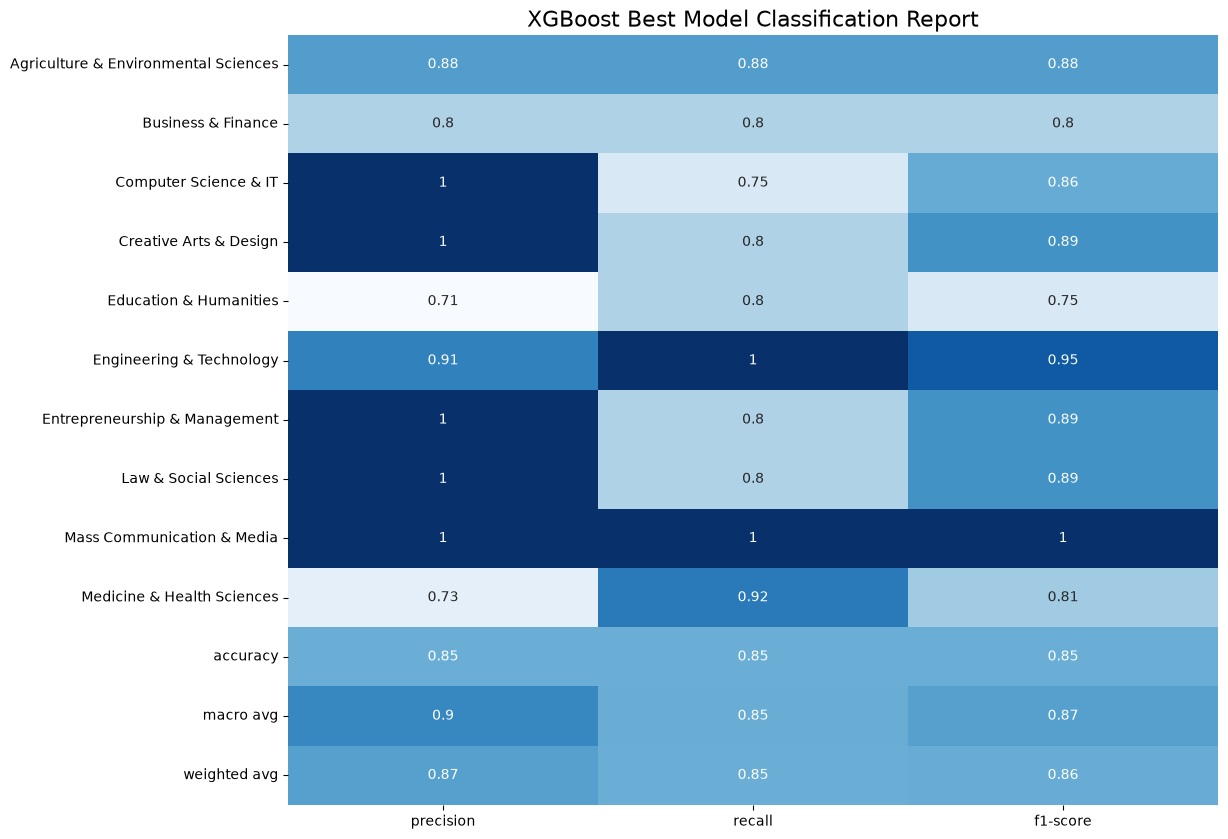

In [138]:
xgb_best_classification_report_dict = classification_report(y_test, xgb_best_model.predict(X_test), target_names=label_encoder.classes_, output_dict=True, zero_division=0)
# Plot Random Forest Classification Report
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pd.DataFrame(xgb_best_classification_report_dict).iloc[:-1, :].T, annot=True, cmap="Blues", cbar=False, ax=ax)
ax.set_title("XGBoost Best Model Classification Report", fontsize=16)
#plt.savefig("ml/models/classification_report.png", dpi=120, bbox_inches="tight")
plt.show()

# Feature importance - XGBoost Tuned Model

Top 20 Feature Importances from XGBOost Tuned Model:


,Features,Importances
0,jamb_score,0.081886
1,french,0.059570
2,government,0.059464
3,intended_career_path,0.051344
4,career_influence,0.049751
5,data_processing,0.048157
6,technical_drawing,0.047208
7,financial_accounting,0.044131
8,christian_religious_studies_islamic_studies,0.039958
9,waec_year,0.038838


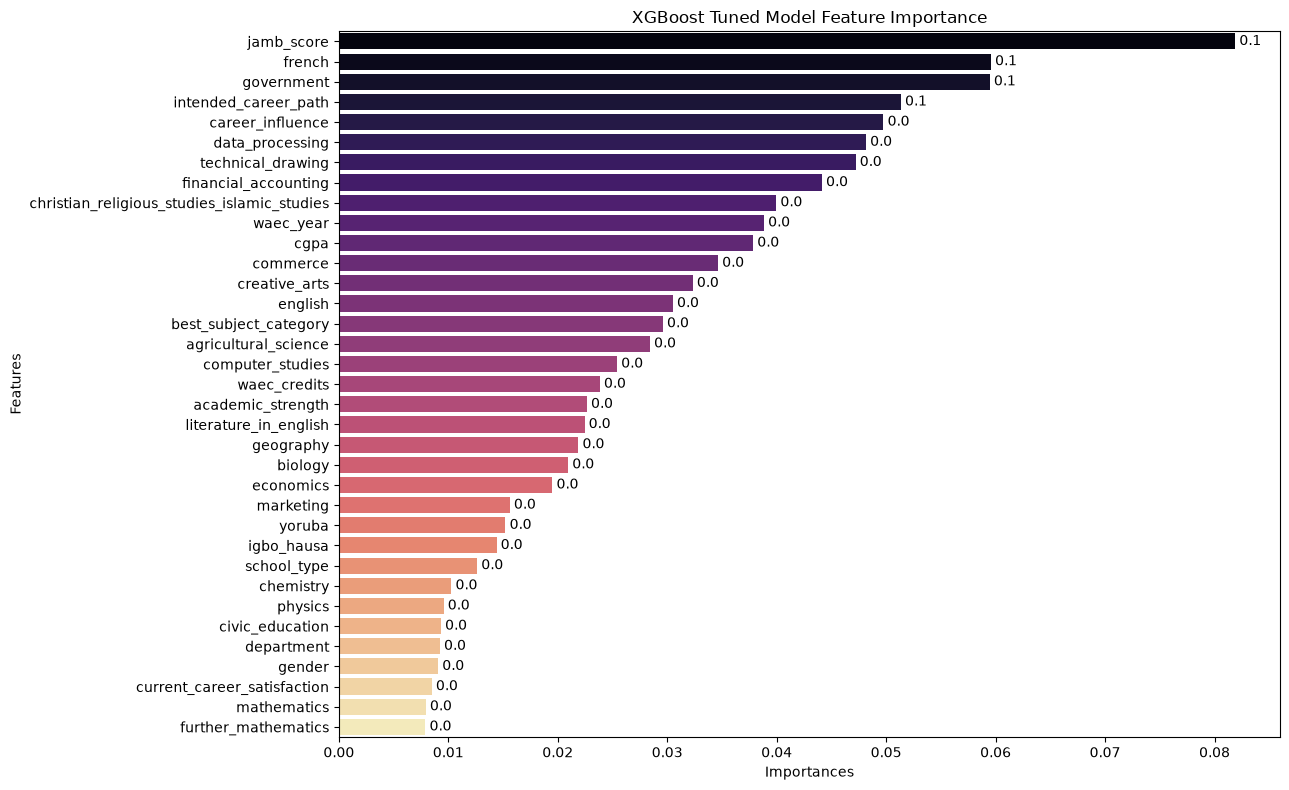

In [139]:
feature_importance = pd.DataFrame({
    'Features': features,
    'Importances': xgb_best_model.named_steps['classifier'].feature_importances_
}).sort_values(by='Importances', ascending=False).reset_index(drop=True)
print('Top 20 Feature Importances from XGBOost Tuned Model:')
display(feature_importance.head(20))

#Plotting XGBoost Tuned Model Feature Importance
plt.figure(figsize=(13, 8))
sns.barplot(x='Importances', y='Features', data=feature_importance, hue='Features', palette='magma', errorbar=None, legend=False)
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f', label_type='edge', padding=3)
plt.title('XGBoost Tuned Model Feature Importance')
plt.xlabel('Importances')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Save Files

In [144]:
import joblib
from pathlib import Path

ROOT_DIR = Path.cwd().resolve()
if not (ROOT_DIR / "new_model.ipynb").exists():
    ROOT_DIR = ROOT_DIR.parent

model_dir = ROOT_DIR / "backend" / "models"
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "xgb_best_model.pkl"
encoder_path = model_dir / "label_encoder.pkl"

joblib.dump(xgb_best_model, model_path)
joblib.dump(label_encoder, encoder_path)

print("Saved model artifacts to:")
print(f"  - {model_path}")
print(f"  - {encoder_path}")

expected = [model_path, encoder_path]
print("Model file checklist:")
for f in expected:
    size = f.stat().st_size if f.exists() else 0
    status = f"✅  {size/1024:.1f} KB" if f.exists() else "❌  MISSING"
    print(f"  {status}  {f}")

Saved model artifacts to:
  - C:\Users\USER\Documents\GitHub uploads\Smart-Career-Portal\backend\models\xgb_best_model.pkl
  - C:\Users\USER\Documents\GitHub uploads\Smart-Career-Portal\backend\models\label_encoder.pkl
Model file checklist:
  ✅  2464.8 KB  C:\Users\USER\Documents\GitHub uploads\Smart-Career-Portal\backend\models\xgb_best_model.pkl
  ✅  0.7 KB  C:\Users\USER\Documents\GitHub uploads\Smart-Career-Portal\backend\models\label_encoder.pkl


# Inference Test - Sample Student Prediction

In [142]:
# Prepare a sample student record using the shared preprocessing function
sample = {
    'Gender': 'Male',
    'School_Type': 'Mission / Faith School',
    'Department': 'Science',
    'Mathematics': 'A',
    'English': 'A',
    'Civic Education': 'D',
    'Physics': 'E',
    'Chemistry': 'A',
    'Biology': 'A',
    'Agricultural Science': 'B',
    'Geography': 'D',
    'Academic_Strength': 'Low',
    'Best_Subject_Category': 'Science',
    'current_career_satisfaction': 'Not very confident',
    'Career_Influence': 'Personal passion'
}

df_sample = pd.DataFrame([sample])

# Add missing columns with sensible defaults
all_expected_cols = [
    'Gender', 'School_Type', 'Department', 'Academic_Strength', 'Best_Subject_Category',
    'Mathematics', 'English', 'Civic Education', 'Physics', 'Chemistry', 'Biology',
    'Further Mathematics', 'Agricultural Science', 'Geography', 'Technical Drawing',
    'Computer Studies', 'Yoruba', 'Igbo / Hausa', 'Data Processing', 'Literature In English',
    'History', 'Christian Religious Studies/Islamic Studies', 'French', 'Creative Arts',
    'Economics', 'Financial Accounting', 'Commerce', 'Government', 'Marketing', 'current_career_satisfaction', 'Career_Influence'
]

for col in all_expected_cols:
    if col not in df_sample.columns:
        df_sample[col] = 'Unknown'

# Grade mapping for all grade columns
grade_map = {'A':8, 'B':6, 'C':5, 'D':3, 'E':2, 'F':1, 'Unknown':5}
grade_cols = [col for col in all_expected_cols if col not in ['Gender','School_Type','Department',
              'Academic_Strength','Best_Subject_Category','current_career_satisfaction','Career_Influence']]

for col in grade_cols:
    if col in df_sample.columns:
        df_sample[col] = df_sample[col].astype(str).str.upper().map(grade_map).fillna(5)

# Use shared preprocessing function for consistent schema handling
sample_frame = df_sample.copy()
sample_frame.columns = [str(c).strip().lower().replace(" ", "_").replace("__", "_") for c in sample_frame.columns]
sample_frame = sample_frame.rename(columns={"igbo_/_hausa": "igbo_hausa"})
df_sample = prepare_feature_frame(sample_frame, features, categorical_columns, numerical_columns)

if sample["Mathematics"] == "F" or sample["English"] == "F":
    print("\nWarning: The student has failed in Mathematics or English. Career recommendations may not be accurate.")
    predicted_career = "None, please improve your grades in Mathematics and English to get career recommendations."
    proba = [0] * len(label_encoder.classes_)
else:
    pred_encoded = xgb_best_model.predict(df_sample)[0]
    proba = xgb_best_model.predict_proba(df_sample)[0]
    predicted_career = label_encoder.inverse_transform([pred_encoded])[0]

print("\n=== SS Student Career Prediction ===")
print(f"**Predicted Career:** {predicted_career}")
print(f"Confidence: {max(proba)*100:.1f}%")

print("\nTop 3:")
for c, p in sorted(zip(label_encoder.classes_, proba), key=lambda x: x[1], reverse=True)[:3]:
    print(f"  • {c} ({p*100:.1f}%)")



=== SS Student Career Prediction ===
**Predicted Career:** Engineering & Technology
Confidence: 29.4%

Top 3:
  • Engineering & Technology (29.4%)
  • Computer Science & IT (16.3%)
  • Agriculture & Environmental Sciences (16.0%)
